In [4]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from src.utils.constants import *

/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:175: UserWarning: 1 rows with missing tokenized IDs will be dropped from 'shapedata'. Dropped original IDs: ['11000']
  warnings.warn(


(<Figure size 1100x900 with 4 Axes>, <Axes: title={'center': 'node: 69'}>)

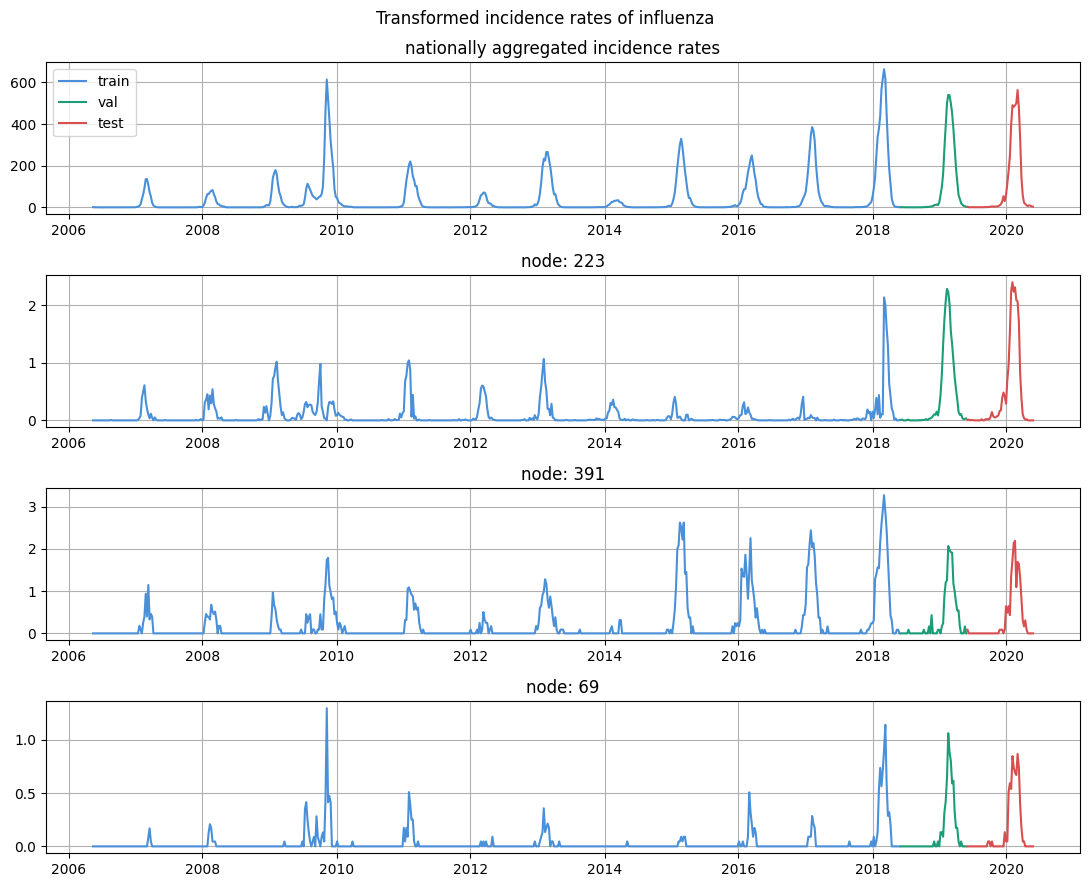

In [5]:
epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2006-05-15',max_date='2020-06-01', include_population=True)
epidata.add_time_features()
epidata.log_transform_target()
epidata.set_splits()
epidata.normalize()
epidata.add_lagged_features(lags = range(1,4))
epidata.finalize()
epidata.preview([token_munich,token_jena,token_oberhausen], status = 'processed_split', y ='incidence')

[0]	train-rmse:0.96306	val-rmse:1.57487
[20]	train-rmse:0.52930	val-rmse:0.80247
[40]	train-rmse:0.42766	val-rmse:0.59023
[60]	train-rmse:0.40486	val-rmse:0.53629
[80]	train-rmse:0.39782	val-rmse:0.52295
[100]	train-rmse:0.39392	val-rmse:0.51878
[120]	train-rmse:0.39093	val-rmse:0.51840
[135]	train-rmse:0.38911	val-rmse:0.51888


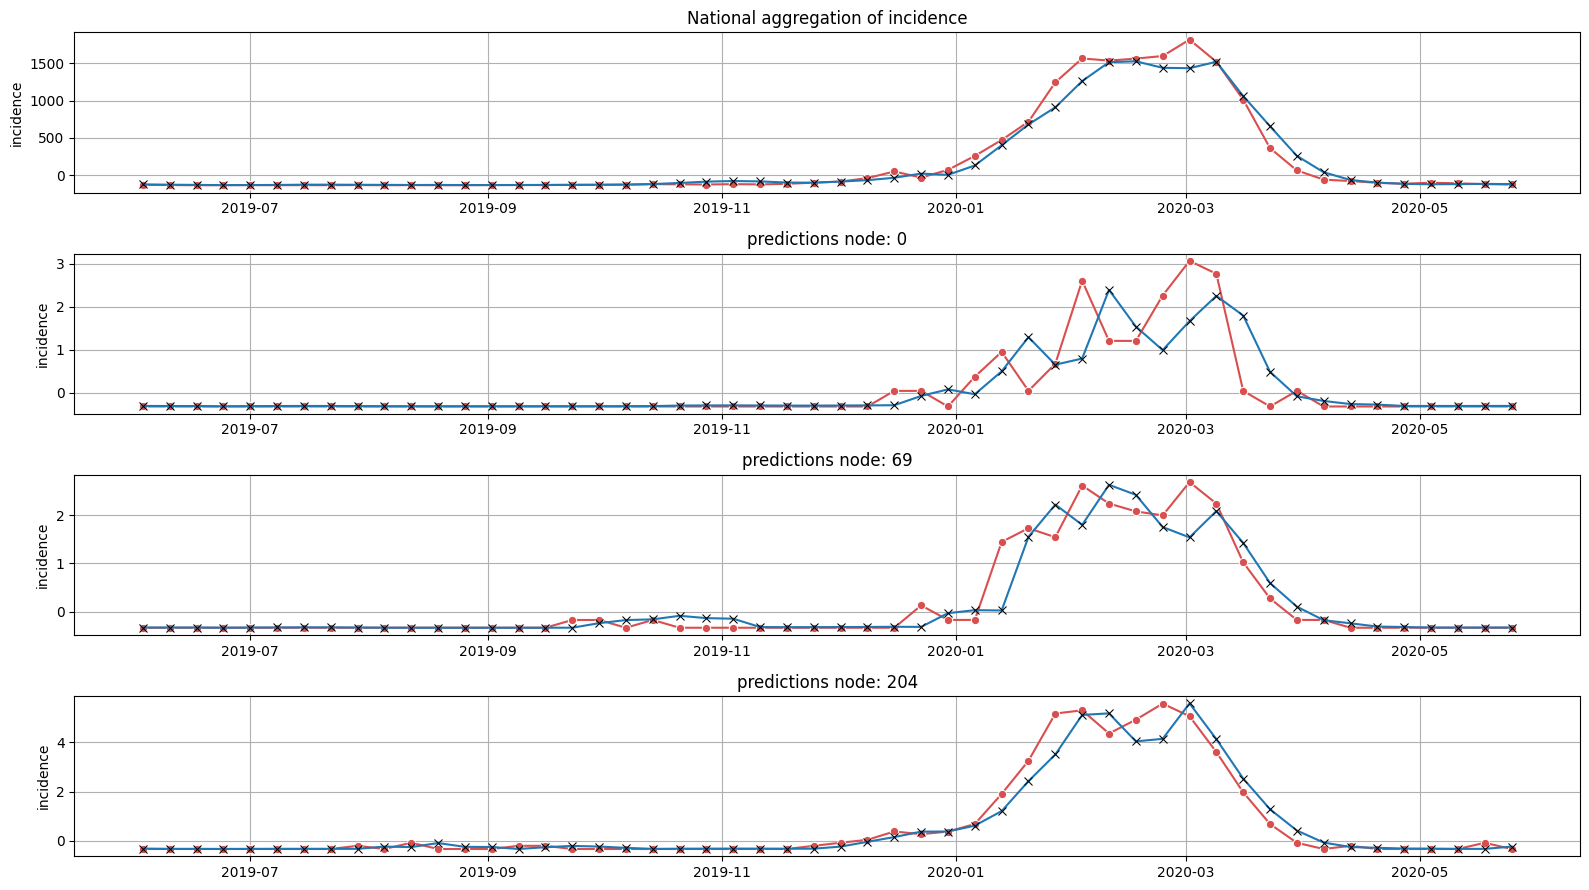

/home/de-schrijvers/projects/germany_gnn/src/models/_basemodel.py:121: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


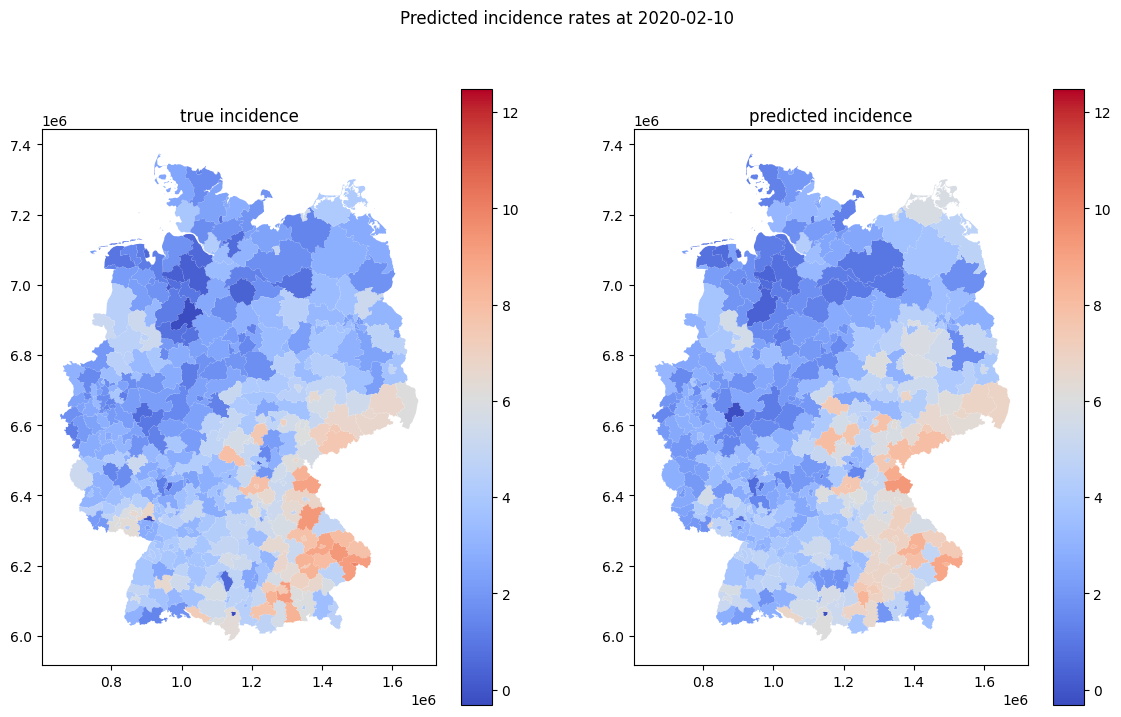

In [7]:
from src.models.xgboostautoregressor import XGBoostAutoRegressor

xgbm = XGBoostAutoRegressor(epidata)

xgbm.set_global_hparams()

xgbm.set_model_hparams()

xgbm.train()

xgbm.forecast('test')
xgbm.forecast('val')
xgbm.forecast('train')
xgbm.show_forecasts('test',[0,69,204])
xgbm.show_forecasts_maps('test',36,'constant')   